In [54]:
!curl -LsSf https://astral.sh/uv/install.sh | bash
%cd /content/
%rm -rf CS-5137-Deep-Learning

!git clone https://github.com/toan-ly/CS-5137-Deep-Learning
%cd CS-5137-Deep-Learning
!uv sync

downloading uv 0.9.7 x86_64-unknown-linux-gnu
no checksums to verify
installing to /usr/local/bin
  uv
  uvx
everything's installed!
/content
Cloning into 'CS-5137-Deep-Learning'...
remote: Enumerating objects: 1222, done.
remote: Counting objects: 100% (30/30), done.
remote: Compressing objects: 100% (21/21), done.
remote: Total 1222 (delta 12), reused 21 (delta 7), pack-reused 1192 (from 1)
Receiving objects: 100% (1222/1222), 171.47 MiB | 15.97 MiB/s, done.
Resolving deltas: 100% (388/388), done.
/content/CS-5137-Deep-Learning
Using CPython 3.11.14
Creating virtual environment at: .venv
Resolved 83 packages in 1ms
Installed 77 packages in 418ms
 + asttokens==3.0.0
 + comm==0.2.3
 + contourpy==1.3.3
 + cycler==0.12.1
 + debugpy==1.8.17
 + decorator==5.2.1
 + executing==2.2.1
 + filelock==3.19.1
 + fonttools==4.59.2
 + fsspec==2025.9.0
 + ipykernel==6.30.1
 + ipython==9.6.0
 + ipython-pygments-lexers==1.1.1
 + jedi==0.19.2
 + jinja2==3.1.6
 + joblib==1.5.2
 + jupyter-client==8.6.3
 + 

In [55]:
%cd /content/CS-5137-Deep-Learning/homework3/
!uv run -m src.train --config configs/train.yaml \
    --data_root ./data \
    --epochs 200 --batch_size 6 --lr 1e-4 \
    --loss tversky+focal+hausdorff@0.6,0.3,0.1 --optimizer adamw \
    --base_channels 50 --depth 3 --up_mode bilinear \
    --block_type base \
    --activation leaky_relu \
    --use_green_channel \
    --early_stopping --patience 20

/content/CS-5137-Deep-Learning/homework3
Loading dataset: 100% 64/64 [00:00<00:00, 75.44it/s]
Loading dataset: 100% 16/16 [00:00<00:00, 67.10it/s]
Image batch shape: torch.Size([14, 1, 512, 512])
Mask batch shape: torch.Size([14, 1, 512, 512])

Image batch shape: torch.Size([14, 1, 512, 512])
Mask batch shape: torch.Size([14, 1, 512, 512])

Model summary:
UNet(
  (activation): LeakyReLU(negative_slope=0.1, inplace=True)
  (encoder): ModuleList(
    (0): DownBlock(
      (double_conv): DoubleConv(
        (double_conv): Sequential(
          (0): Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
          (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
          (2): LeakyReLU(negative_slope=0.1, inplace=True)
          (3): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
          (4): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
          (5): LeakyReLU(negative_slope=0.1, inplace=

In [56]:
import pandas as pd
import matplotlib.pyplot as plt
import os

def plot_loss(loss_df, save_dir):
    fig, axs = plt.subplots(1, 3, figsize=(12, 4))
    axs[0].plot(loss_df['epoch'], loss_df['train_loss'], label='train_loss')
    axs[0].plot(loss_df['epoch'], loss_df['val_loss'], label='val_loss')
    axs[0].set_xlabel('Epoch')
    axs[0].set_ylabel('Loss')
    axs[0].set_title('Training and Validation Loss')
    axs[0].legend()

    axs[1].plot(loss_df['epoch'], loss_df['train_dice'], label='train_dice')
    axs[1].plot(loss_df['epoch'], loss_df['val_dice'], label='val_dice')
    axs[1].set_xlabel('Epoch')
    axs[1].set_ylabel('Dice')
    axs[1].set_title('Training and Validation Dice')
    axs[1].legend()

    axs[2].plot(loss_df['epoch'], loss_df['train_iou'], label='train_iou')
    axs[2].plot(loss_df['epoch'], loss_df['val_iou'], label='val_iou')
    axs[2].set_xlabel('Epoch')
    axs[2].set_ylabel('IoU')
    axs[2].set_title('Training and Validation IoU')
    axs[2].legend()

    plt.tight_layout()
    # plt.savefig(os.path.join(save_dir, 'train_curve.png'))
    plt.show()

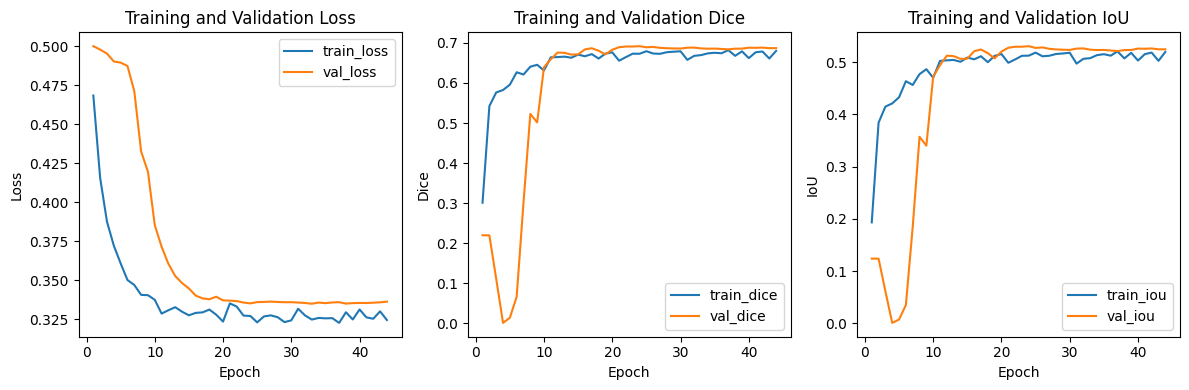

In [57]:
history_df = pd.read_csv('checkpoints/training_history.csv')
plot_loss(history_df, 'checkpoints')

# Download weights

In [58]:
from google.colab import files
%cd checkpoints
!zip -r checkpoints.zip *
files.download('checkpoints.zip')

/content/CS-5137-Deep-Learning/homework3/checkpoints
  adding: best_model.pth (deflated 9%)
  adding: training_history.csv (deflated 51%)


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>